SCENARIO 1 – APRIORI (Association Rule Mining)

Import Libraries

In [ ]:
print("Akhilon S - 24BAD008")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Load Dataset

In [ ]:
print("Akhilon S - 24BAD008")
data = pd.read_csv("C:\ML_Lab\Groceries_dataset.csv")
print(data.head())

   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


Data Preprocessing (One-Hot Encoding)

In [ ]:
print("Akhilon S - 24BAD008")
# Group items by Transaction ID
transactions = data.groupby('Member_number')['itemDescription'].apply(list)

# Convert to list format
transactions = transactions.tolist()

# One-hot encoding
te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_data, columns=te.columns_)
print(df.head())

   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics   bags  baking powder  bathroom cleaner   beef  berries  \
0           False  False          False             False  False    False   
1           False  False          False             False   True    False   
2           False  False          False             False  False    False   
3           False  False          False             False  False    False   
4           False  False          False             False  False    False   

   ...  turkey  vinegar  waffles  whipped/sour cream  whisky  white bread  \
0  ...   False 

Task 4 & 5: Frequent Itemsets

In [5]:
print("Akhilon S - 24BAD008")
frequent_itemsets = apriori(df, min_support=0.02, use_colnames=True)
print(frequent_itemsets.head())

Akhilon S - 24BAD008
    support         itemsets
0  0.078502       (UHT-milk)
1  0.031042  (baking powder)
2  0.119548           (beef)
3  0.079785        (berries)
4  0.062083      (beverages)


Task 6: Generate Association Rules

In [6]:
print("Akhilon S - 24BAD008")
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
print(rules.head())

Akhilon S - 24BAD008
  antecedents         consequents  antecedent support  consequent support  \
0  (UHT-milk)  (other vegetables)            0.078502            0.376603   
1  (UHT-milk)        (rolls/buns)            0.078502            0.349666   
2  (UHT-milk)              (soda)            0.078502            0.313494   
3  (UHT-milk)        (whole milk)            0.078502            0.458184   
4      (beef)  (other vegetables)            0.119548            0.376603   

    support  confidence      lift  leverage  conviction  zhangs_metric  
0  0.038994    0.496732  1.318979  0.009430    1.238697       0.262440  
1  0.031042    0.395425  1.130863  0.003592    1.075687       0.125578  
2  0.027450    0.349673  1.115406  0.002840    1.055632       0.112280  
3  0.040534    0.516340  1.126928  0.004565    1.120242       0.122227  
4  0.050795    0.424893  1.128223  0.005773    1.083966       0.129082  


Task 7: Filter Rules

In [7]:
print("Akhilon S - 24BAD008")
strong_rules = rules[(rules['confidence'] > 0.5) & (rules['lift'] > 1)]
print(strong_rules)

Akhilon S - 24BAD008
                       antecedents   consequents  antecedent support  \
3                       (UHT-milk)  (whole milk)            0.078502   
7                           (beef)  (whole milk)            0.119548   
22                  (bottled beer)  (whole milk)            0.158799   
28                 (bottled water)  (whole milk)            0.213699   
33                   (brown bread)  (whole milk)            0.135967   
..                             ...           ...                 ...   
855    (sausage, soda, whole milk)  (rolls/buns)            0.040021   
858    (sausage, soda, rolls/buns)  (whole milk)            0.035916   
860  (yogurt, whole milk, sausage)  (rolls/buns)            0.044895   
862  (yogurt, rolls/buns, sausage)  (whole milk)            0.035659   
867     (yogurt, soda, rolls/buns)  (whole milk)            0.042329   

     consequent support   support  confidence      lift  leverage  conviction  \
3              0.458184  0.040534

Task 8: Interpret Rules

In [8]:
print("Akhilon S - 24BAD008")
for i, row in strong_rules.iterrows():
    print(f"If {set(row['antecedents'])} then {set(row['consequents'])}")
    print(f"Support: {row['support']}, Confidence: {row['confidence']}, Lift: {row['lift']}\n")

Akhilon S - 24BAD008
If {'UHT-milk'} then {'whole milk'}
Support: 0.040533606977937404, Confidence: 0.5163398692810458, Lift: 1.1269276654297404

If {'beef'} then {'whole milk'}
Support: 0.06413545407901487, Confidence: 0.5364806866952789, Lift: 1.1708856196742425

If {'bottled beer'} then {'whole milk'}
Support: 0.08542842483324782, Confidence: 0.5379644588045235, Lift: 1.174123997995539

If {'bottled water'} then {'whole milk'}
Support: 0.11236531554643407, Confidence: 0.5258103241296519, Lift: 1.1475972247801696

If {'brown bread'} then {'whole milk'}
Support: 0.06977937403796819, Confidence: 0.5132075471698113, Lift: 1.1200912759618837

If {'butter'} then {'whole milk'}
Support: 0.06618778860954336, Confidence: 0.5233265720081136, Lift: 1.142176359287585

If {'candy'} then {'whole milk'}
Support: 0.029245767060030785, Confidence: 0.5428571428571429, Lift: 1.1848024316109425

If {'canned beer'} then {'whole milk'}
Support: 0.08722421754746024, Confidence: 0.5279503105590062, Lift: 1

Visualization 1: Frequent Itemsets Bar Chart

Akhilon S - 24BAD008


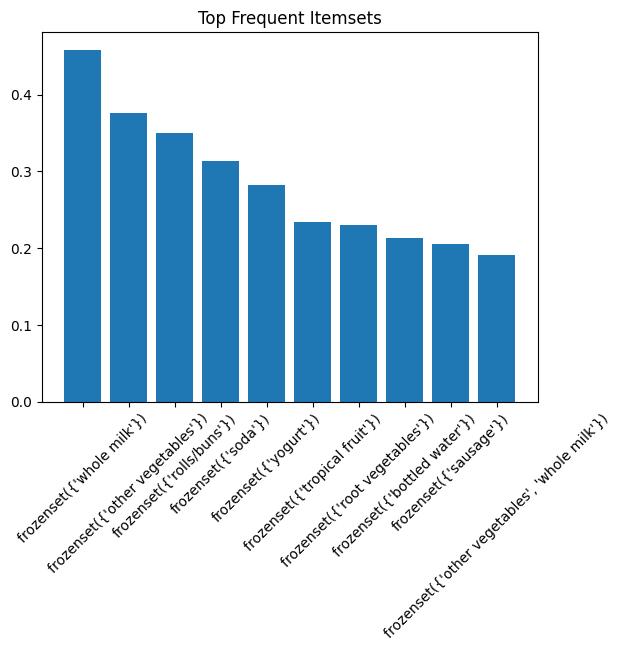

In [9]:
print("Akhilon S - 24BAD008")
top_items = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

plt.bar(range(len(top_items)), top_items['support'])
plt.xticks(range(len(top_items)), top_items['itemsets'], rotation=45)
plt.title("Top Frequent Itemsets")
plt.show()

Visualization 2: Support vs Confidence

Akhilon S - 24BAD008


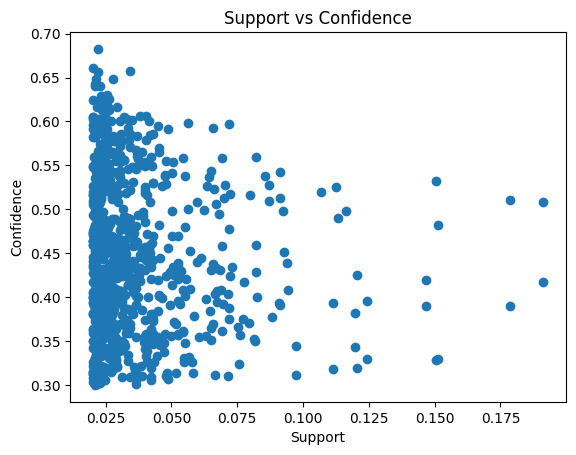

In [10]:
print("Akhilon S - 24BAD008")
plt.scatter(rules['support'], rules['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()

Visualization 3: Network Graph

Akhilon S - 24BAD008


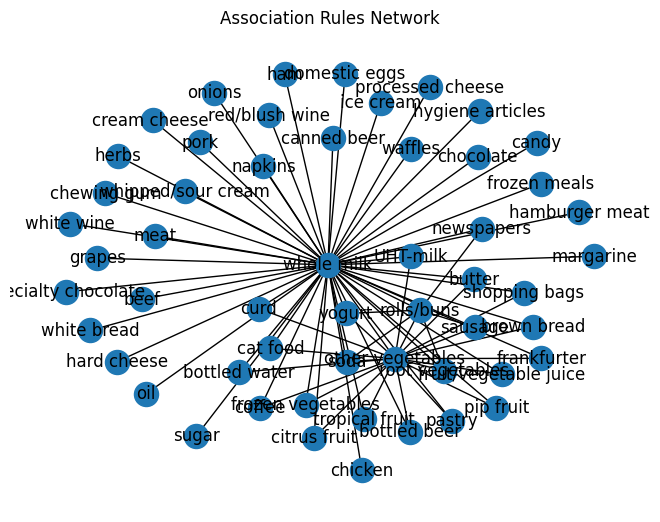

In [11]:
print("Akhilon S - 24BAD008")
import networkx as nx

G = nx.Graph()

for _, row in strong_rules.iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c)

nx.draw(G, with_labels=True)
plt.title("Association Rules Network")
plt.show()

SCENARIO 2 – PCA (Dimensionality Reduction)

Load Grocery Dataset

In [12]:
print("Akhilon S - 24BAD008")
data = pd.read_csv("Groceries_dataset.csv")
print(data.head())

Akhilon S - 24BAD008
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


Task 2: Preprocessing (Convert to One-Hot Encoding)

In [13]:
print("Akhilon S - 24BAD008")
# Group transactions
transactions = data.groupby('Member_number')['itemDescription'].apply(list)
transactions = transactions.tolist()

# Unique items
items = sorted(set(item for t in transactions for item in t))

# One-hot encoding
encoded_data = []
for t in transactions:
    row = [1 if item in t else 0 for item in items]
    encoded_data.append(row)

df = pd.DataFrame(encoded_data, columns=items)

print(df.head())

Akhilon S - 24BAD008
   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                      0         0                 0                 0   
1                      0         0                 0                 0   
2                      0         0                 0                 0   
3                      0         0                 0                 0   
4                      0         0                 0                 0   

   baby cosmetics  bags  baking powder  bathroom cleaner  beef  berries  ...  \
0               0     0              0                 0     0        0  ...   
1               0     0              0                 0     1        0  ...   
2               0     0              0                 0     0        0  ...   
3               0     0              0                 0     0        0  ...   
4               0     0              0                 0     0        0  ...   

   turkey  vinegar  waffles  whipped/sour cream  whis

Task 3: Standardization

In [14]:
print("Akhilon S - 24BAD008")
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Akhilon S - 24BAD008


Task 4 & 5: Apply PCA

In [15]:
print("Akhilon S - 24BAD008")
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

Akhilon S - 24BAD008


Task 6: Explained Variance

In [17]:
print("Akhilon S - 24BAD008")
explained_variance = pca.explained_variance_ratio_
print(explained_variance[:10])  # first 10 components

Akhilon S - 24BAD008
[0.01592942 0.00875797 0.00869744 0.00868125 0.00857885 0.00850037
 0.00838747 0.00836396 0.00825556 0.00823771]


Task 7: Reduce Dimensions (2D)

In [18]:
print("Akhilon S - 24BAD008")
pca_2 = PCA(n_components=2)
X_reduced = pca_2.fit_transform(X_scaled)

Akhilon S - 24BAD008


Visualization 1: Scree Plot

Akhilon S - 24BAD008


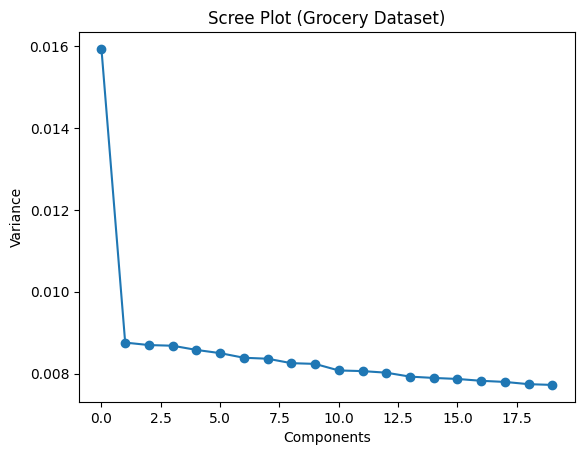

In [19]:
print("Akhilon S - 24BAD008")
plt.plot(explained_variance[:20], marker='o')
plt.title("Scree Plot (Grocery Dataset)")
plt.xlabel("Components")
plt.ylabel("Variance")
plt.show()

Visualization 2: 2D Scatter Plot

Akhilon S - 24BAD008


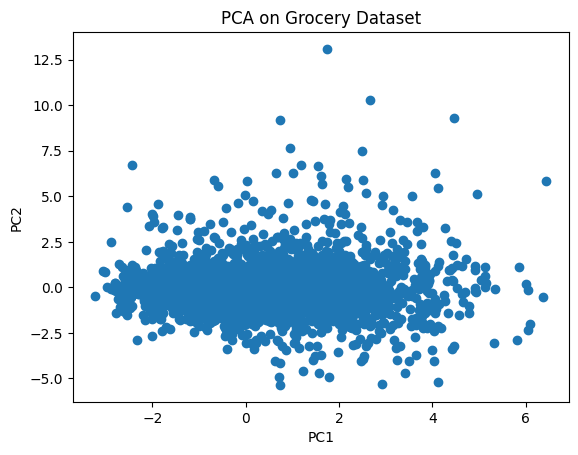

In [20]:
print("Akhilon S - 24BAD008")
plt.scatter(X_reduced[:, 0], X_reduced[:, 1])
plt.title("PCA on Grocery Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Visualization 3: Cumulative Variance

Akhilon S - 24BAD008


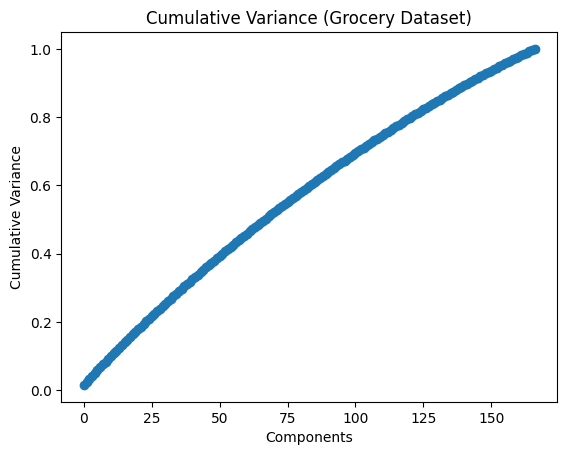

In [21]:
print("Akhilon S - 24BAD008")
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance, marker='o')
plt.title("Cumulative Variance (Grocery Dataset)")
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.show()